# Assignment 4: Regularization

In [1]:
! git clone https://github.com/JasonYe05/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 33 (delta 9), reused 5 (delta 5), pack-reused 20 (from 1)
Receiving objects: 100% (33/33), 32.57 KiB | 1010.00 KiB/s, done.
Resolving deltas: 100% (10/10), done.
Download complete
Extracting data files...
Data extracted


**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. You "Charge" the model for buying bigger coefficients and making the complex models expensive.
2. Regularizing cuts/reduces the variance by shrinking the coefficients towards 0.
3. Ridge shrinks well and is usually better at predictions. LASSO can send coefficients to zero as well as pick a model for you.
4. You want z-scores to normalize the numberic variables. Why? Because scale can affect the penatly comparison as well as the interpretation of alpha.
5. We use cross validations to choos the alpha that would minimize cross validated MSE.
6. You fit based on the penalized objective on the folds, then evaluate the plain MSE on the test folds.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso

df = pd.read_csv("/content/data/cars_hw.csv")

In [3]:
df["Age"] = 2024 - df["Make_Year"]

X_raw = df[["Mileage_Run", "Age"]]
y = df["Price"]

In [4]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_raw)
feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])

In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(X_poly)

In [6]:
linreg = LinearRegression()
linreg.fit(X, y)

lin_coefs = pd.Series(linreg.coef_, index=feature_names)
print("Linear regression coefficients:")
print(lin_coefs)

Linear regression coefficients:
Mileage_Run          6.686165e+05
Age                 -1.841941e+05
Mileage_Run^2       -1.494679e+05
Mileage_Run Age     -1.251592e+06
Age^2                2.156399e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    2.833392e+05
Mileage_Run Age^2    5.280829e+05
Age^3               -1.389370e+05
dtype: float64


The interaction between milage run and age is negative

In [7]:
alphas = np.logspace(1, 3, 20)

lasso_cv = LassoCV(
    alphas=alphas,
    cv=20,
    max_iter=200000,
    random_state=0
)
lasso_cv.fit(X, y)

lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)

print("\nBest alpha:")
print(lasso_cv.alpha_)

print("\nLASSO coefficients:")
print(lasso_coefs)


Best alpha:
483.2930238571752

LASSO coefficients:
Mileage_Run          401025.259657
Age                 -194803.116695
Mileage_Run^2        -62539.290093
Mileage_Run Age     -578788.661090
Age^2                    -0.000000
Mileage_Run^3            -0.000000
Mileage_Run^2 Age         0.000000
Mileage_Run Age^2    292015.025679
Age^3                 19133.908573
dtype: float64


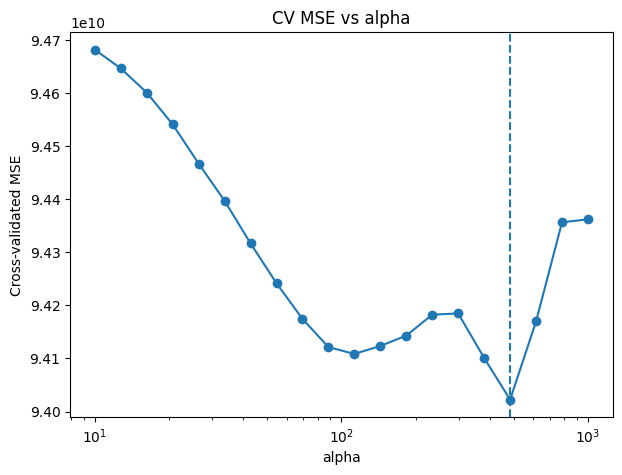

In [8]:
mean_mse = lasso_cv.mse_path_.mean(axis=1)

plt.figure(figsize=(7,5))
plt.semilogx(lasso_cv.alphas_, mean_mse, marker="o")
plt.axvline(lasso_cv.alpha_, linestyle="--")
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("CV MSE vs alpha")
plt.show()


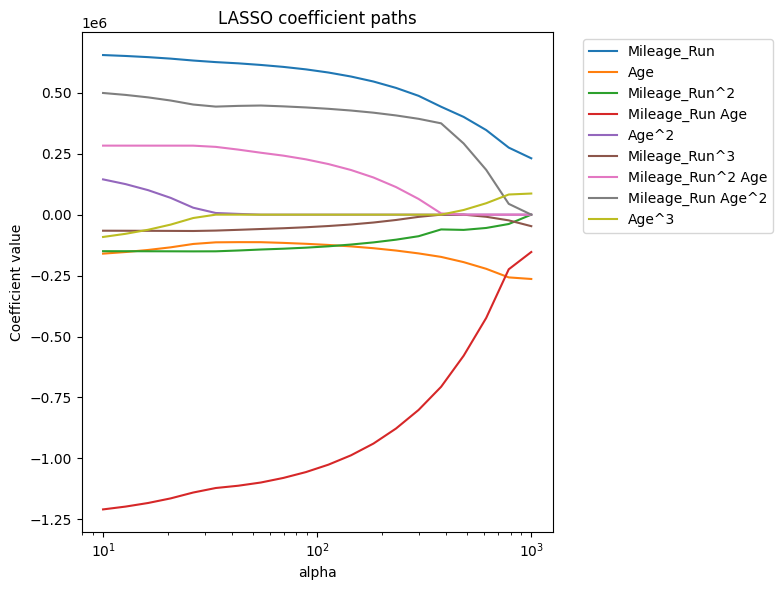

In [9]:
coef_path = []
for a in alphas:
    model = Lasso(alpha=a, max_iter=200000)
    model.fit(X, y)
    coef_path.append(model.coef_)

coef_path = np.array(coef_path)

plt.figure(figsize=(8,6))
for j, name in enumerate(feature_names):
    plt.semilogx(alphas, coef_path[:, j], label=name)
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO coefficient paths")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [10]:
selected = lasso_coefs[lasso_coefs != 0]
prop_zero = (lasso_coefs == 0).mean()

print("\nSelected features:")
print(selected)

print("\nProportion set to zero:")
print(prop_zero)



Selected features:
Mileage_Run          401025.259657
Age                 -194803.116695
Mileage_Run^2        -62539.290093
Mileage_Run Age     -578788.661090
Mileage_Run Age^2    292015.025679
Age^3                 19133.908573
dtype: float64

Proportion set to zero:
0.3333333333333333


Optimal: Mileage_Run, Age, Mileage_Run^2, Mileage_Run Age, Mileage_Run Age^2, Age^3. Set to 0: Age^2, Mileage_Run^3, Mileage_Run^2 Age. Proportion is 1/3

In [11]:
comparison = pd.DataFrame({
    "Linear": lin_coefs,
    "LASSO": lasso_coefs
})
comparison["Linear_abs"] = comparison["Linear"].abs()
comparison["LASSO_abs"] = comparison["LASSO"].abs()
comparison["Abs_increase"] = comparison["LASSO_abs"] > comparison["Linear_abs"]
comparison["Sign_change"] = np.sign(comparison["Linear"]) != np.sign(comparison["LASSO"])

print("\nComparison:")
print(comparison)


Comparison:
                         Linear          LASSO    Linear_abs      LASSO_abs  \
Mileage_Run        6.686165e+05  401025.259657  6.686165e+05  401025.259657   
Age               -1.841941e+05 -194803.116695  1.841941e+05  194803.116695   
Mileage_Run^2     -1.494679e+05  -62539.290093  1.494679e+05   62539.290093   
Mileage_Run Age   -1.251592e+06 -578788.661090  1.251592e+06  578788.661090   
Age^2              2.156399e+05      -0.000000  2.156399e+05       0.000000   
Mileage_Run^3     -6.514490e+04      -0.000000  6.514490e+04       0.000000   
Mileage_Run^2 Age  2.833392e+05       0.000000  2.833392e+05       0.000000   
Mileage_Run Age^2  5.280829e+05  292015.025679  5.280829e+05  292015.025679   
Age^3             -1.389370e+05   19133.908573  1.389370e+05   19133.908573   

                   Abs_increase  Sign_change  
Mileage_Run               False        False  
Age                        True        False  
Mileage_Run^2             False        False  
Mileage_

Yes Age increase in value by a little, Age^3 sign changes.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [12]:
alphas = np.logspace(-5, 5, 30)

In [13]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

In [14]:
y = df["DEATH_EVENT"]

X_num_raw = df[["age", "ejection_fraction", "serum_creatinine"]]

poly_num = PolynomialFeatures(degree=3, include_bias=False)
X_num_poly = poly_num.fit_transform(X_num_raw)
num_feature_names = poly_num.get_feature_names_out(X_num_raw.columns)

scaler = StandardScaler()
X_num = scaler.fit_transform(X_num_poly)

X_cat_raw = df[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]

poly_cat = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_cat = poly_cat.fit_transform(X_cat_raw)
cat_feature_names = poly_cat.get_feature_names_out(X_cat_raw.columns)

X = np.concatenate([X_num, X_cat], axis=1)
feature_names = list(num_feature_names) + list(cat_feature_names)

In [15]:
linreg = LinearRegression()
linreg.fit(X, y)
lin_coefs = pd.Series(linreg.coef_, index=feature_names)

print("Linear regression coefficients")
print(lin_coefs)

Linear regression coefficients
age                                       1.539156
ejection_fraction                        -2.192494
serum_creatinine                         -0.853588
age^2                                    -3.678654
age ejection_fraction                    -0.600918
age serum_creatinine                      1.841563
ejection_fraction^2                       3.430976
ejection_fraction serum_creatinine        2.673394
serum_creatinine^2                       -2.647041
age^3                                     1.993135
age^2 ejection_fraction                   0.908026
age^2 serum_creatinine                   -0.697522
age ejection_fraction^2                  -0.081206
age ejection_fraction serum_creatinine   -1.577665
age serum_creatinine^2                    1.284099
ejection_fraction^3                      -1.250341
ejection_fraction^2 serum_creatinine     -1.270043
ejection_fraction serum_creatinine^2      1.179475
serum_creatinine^3                        0.072156


The higher order terms explains the contradicition in this set. Live a variable can have a negative linear term but also a positive quadratic or cubic behavior over some parts of the range.

In [16]:
alphas = np.logspace(-5, 5, 30)

lasso_cv = LassoCV(
    alphas=alphas,
    cv=20,
    max_iter=500000,
    random_state=0
)
lasso_cv.fit(X, y)

lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)

print("\nBest alpha")
print(lasso_cv.alpha_)

print("\nLASSO coefficients")
print(lasso_coefs)


Best alpha
0.005736152510448681

LASSO coefficients
age                                      -0.000000
ejection_fraction                        -0.329656
serum_creatinine                          0.116875
age^2                                     0.000000
age ejection_fraction                    -0.000000
age serum_creatinine                      0.000000
ejection_fraction^2                       0.000000
ejection_fraction serum_creatinine        0.000000
serum_creatinine^2                       -0.000000
age^3                                     0.117992
age^2 ejection_fraction                   0.000000
age^2 serum_creatinine                    0.000000
age ejection_fraction^2                   0.000000
age ejection_fraction serum_creatinine    0.000000
age serum_creatinine^2                   -0.000000
ejection_fraction^3                       0.204822
ejection_fraction^2 serum_creatinine      0.032801
ejection_fraction serum_creatinine^2     -0.000000
serum_creatinine^3           

The best penatly with 20 fold cross validation is alpha = 0.005736

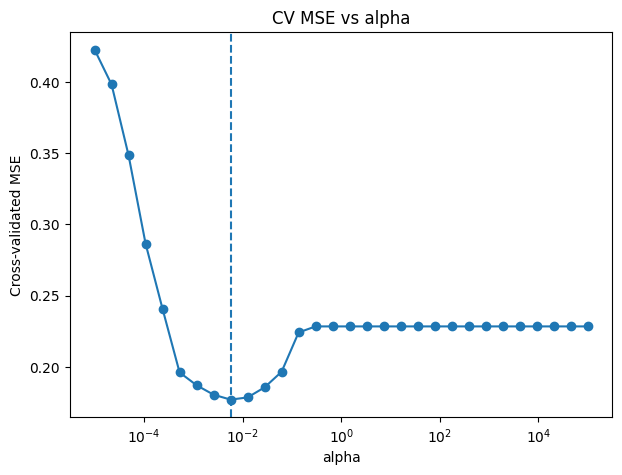

In [17]:
mean_mse = lasso_cv.mse_path_.mean(axis=1)

plt.figure(figsize=(7,5))
plt.semilogx(lasso_cv.alphas_, mean_mse, marker="o")
plt.axvline(lasso_cv.alpha_, linestyle="--")
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("CV MSE vs alpha")
plt.show()

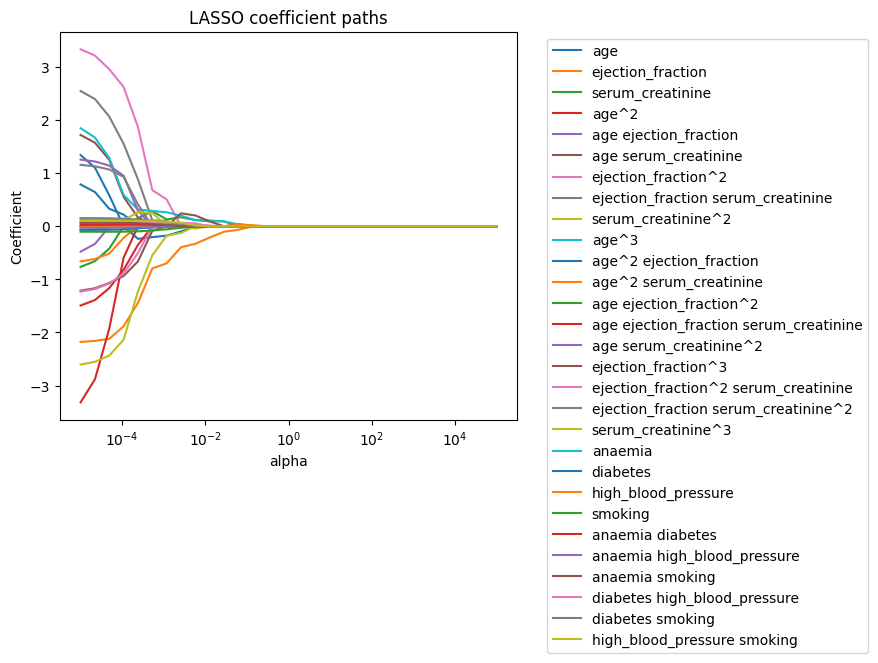

In [18]:
coef_path = []
for a in alphas:
    model = Lasso(alpha=a, max_iter=500000)
    model.fit(X, y)
    coef_path.append(model.coef_)

coef_path = np.array(coef_path)

plt.figure(figsize=(9,6))
for j, name in enumerate(feature_names):
    plt.semilogx(alphas, coef_path[:, j], label=name)
plt.xlabel("alpha")
plt.ylabel("Coefficient")
plt.title("LASSO coefficient paths")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [19]:
selected = lasso_coefs[lasso_coefs != 0]
prop_zero = (lasso_coefs == 0).mean()

comparison = pd.DataFrame({
    "Linear": lin_coefs,
    "LASSO": lasso_coefs
})
comparison["Linear_abs"] = comparison["Linear"].abs()
comparison["LASSO_abs"] = comparison["LASSO"].abs()
comparison["Abs_increase"] = comparison["LASSO_abs"] > comparison["Linear_abs"]
comparison["Sign_change"] = np.sign(comparison["Linear"]) != np.sign(comparison["LASSO"])

print("\nSelected features")
print(selected)

print("\nProportion set to zero")
print(prop_zero)

print("\nComparison")
print(comparison)


Selected features
ejection_fraction                      -0.329656
serum_creatinine                        0.116875
age^3                                   0.117992
ejection_fraction^3                     0.204822
ejection_fraction^2 serum_creatinine    0.032801
serum_creatinine^3                     -0.043266
anaemia                                 0.014178
diabetes                                0.000607
high_blood_pressure                     0.013608
diabetes high_blood_pressure            0.053968
diabetes smoking                        0.003466
high_blood_pressure smoking             0.017805
dtype: float64

Proportion set to zero
0.5862068965517241

Comparison
                                          Linear     LASSO  Linear_abs  \
age                                     1.539156 -0.000000    1.539156   
ejection_fraction                      -2.192494 -0.329656    2.192494   
serum_creatinine                       -0.853588  0.116875    0.853588   
age^2                      

12/29 coefficints are kept. Which means 17/29 are set to zero. ejection_fraction^3 changes negative to positve, serum_creatinine chages negative to positive, serum_creatinine chages positve to negative, ejection_fraction^2 serum_creatinine changes negative to positive, high_blood_pressure changes negative to positive, and diabetes changes negative to positive. None of the selected coefficients increased in magnitude from the linear regression to LASSO except anaemia. Everything else gets smaller or is at zero.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?